# Module 5B — Loan Default Prediction
## Decision Trees, Random Forests, Class Imbalance & Advanced Accuracy Techniques
**Domain:** Predicting loan default at a Jordanian microfinance institution  
**Dataset:** 200,000 synthetic applicants with ~8% default rate

---
## Section 1 — Data Generation

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 200_000

monthly_income     = np.random.lognormal(mean=7.0, sigma=0.5, size=n).round(0)
employment_years   = np.random.exponential(scale=5, size=n).round(1)
loan_amount        = np.random.uniform(500, 15000, n).round(0)
credit_score       = np.random.normal(650, 80, n).clip(300, 850).round(0)
prior_defaults     = np.random.choice([0, 1, 2, 3], n, p=[0.7, 0.15, 0.1, 0.05])
has_collateral     = np.random.choice([0, 1], n, p=[0.4, 0.6])
region             = np.random.choice(
    ["Amman", "Irbid", "Zarqa", "Aqaba", "Mafraq"], n,
    p=[0.35, 0.2, 0.2, 0.15, 0.1]
)

default_prob = 1 / (1 + np.exp(
    2.0
    - 0.0003 * monthly_income
    - 0.005  * credit_score
    + 0.8    * prior_defaults
    + 0.0002 * loan_amount
    - 0.05   * employment_years
    - 0.3    * has_collateral
    + np.random.normal(0, 0.3, n)
))
defaulted = (np.random.random(n) < default_prob).astype(int)

loans = pd.DataFrame({
    "monthly_income":   monthly_income,
    "employment_years": employment_years,
    "loan_amount":      loan_amount,
    "credit_score":     credit_score,
    "prior_defaults":   prior_defaults,
    "has_collateral":   has_collateral,
    "region":           region,
    "defaulted":        defaulted,
})

print(loans.shape)
print(f"Default rate: {defaulted.mean():.1%}")
print(loans.describe().round(1))

/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


(200000, 8)
Default rate: 52.4%
       monthly_income  employment_years  loan_amount  credit_score  \
count        200000.0          200000.0     200000.0      200000.0   
mean           1243.1               5.0       7751.3         650.0   
std             660.7               5.0       4181.9          79.5   
min             118.0               0.0        500.0         304.0   
25%             783.0               1.4       4134.0         596.0   
50%            1098.0               3.5       7745.0         650.0   
75%            1538.0               6.9      11369.0         704.0   
max           10733.0              60.7      15000.0         850.0   

       prior_defaults  has_collateral  defaulted  
count        200000.0        200000.0   200000.0  
mean              0.5             0.6        0.5  
std               0.9             0.5        0.5  
min               0.0             0.0        0.0  
25%               0.0             0.0        0.0  
50%               0.0          

---
## Section 2 — Exploration & Class Imbalance

Default rate:  52.4%
Defaults:      104,872 out of 200,000

Class distribution:
defaulted
1    104872
0     95128
Name: count, dtype: int64


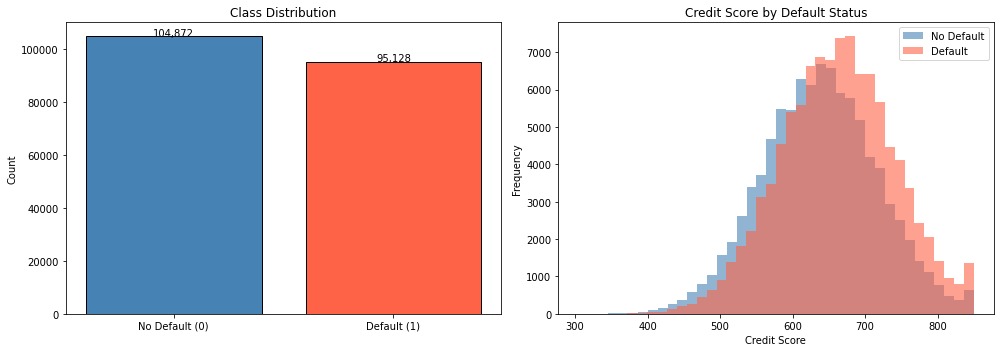

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Default rate:  {loans['defaulted'].mean():.1%}")
print(f"Defaults:      {loans['defaulted'].sum():,} out of {len(loans):,}")
print()
print("Class distribution:")
print(loans['defaulted'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution bar chart
counts = loans['defaulted'].value_counts()
axes[0].bar(
    ["No Default (0)", "Default (1)"],
    counts.values,
    color=["steelblue", "tomato"],
    edgecolor="black"
)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontsize=10)

# Credit score distribution by class
loans[loans["defaulted"] == 0]["credit_score"].plot(
    kind="hist", bins=40, alpha=0.6, color="steelblue",
    label="No Default", ax=axes[1]
)
loans[loans["defaulted"] == 1]["credit_score"].plot(
    kind="hist", bins=40, alpha=0.6, color="tomato",
    label="Default", ax=axes[1]
)
axes[1].set_title("Credit Score by Default Status")
axes[1].set_xlabel("Credit Score")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Section 3 — Train / Test Split

In [3]:
from sklearn.model_selection import train_test_split

X = loans[[
    "monthly_income", "employment_years", "loan_amount",
    "credit_score", "prior_defaults", "has_collateral"
]]
y = loans["defaulted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:  {X_train.shape[0]:,} samples")
print(f"Test set:      {X_test.shape[0]:,} samples")
print(f"Train default rate: {y_train.mean():.1%}")
print(f"Test  default rate: {y_test.mean():.1%}")

Training set:  160,000 samples
Test set:      40,000 samples
Train default rate: 52.4%
Test  default rate: 52.4%


---
## Section 4 — Decision Tree: Baseline & Visualization

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Decision Tree (max_depth=5) — Classification Report")
print(classification_report(y_test, y_pred_tree, target_names=["no_default", "default"]))

Decision Tree (max_depth=5) — Classification Report
              precision    recall  f1-score   support

  no_default       0.69      0.65      0.67     19026
     default       0.70      0.73      0.71     20974

    accuracy                           0.69     40000
   macro avg       0.69      0.69      0.69     40000
weighted avg       0.69      0.69      0.69     40000



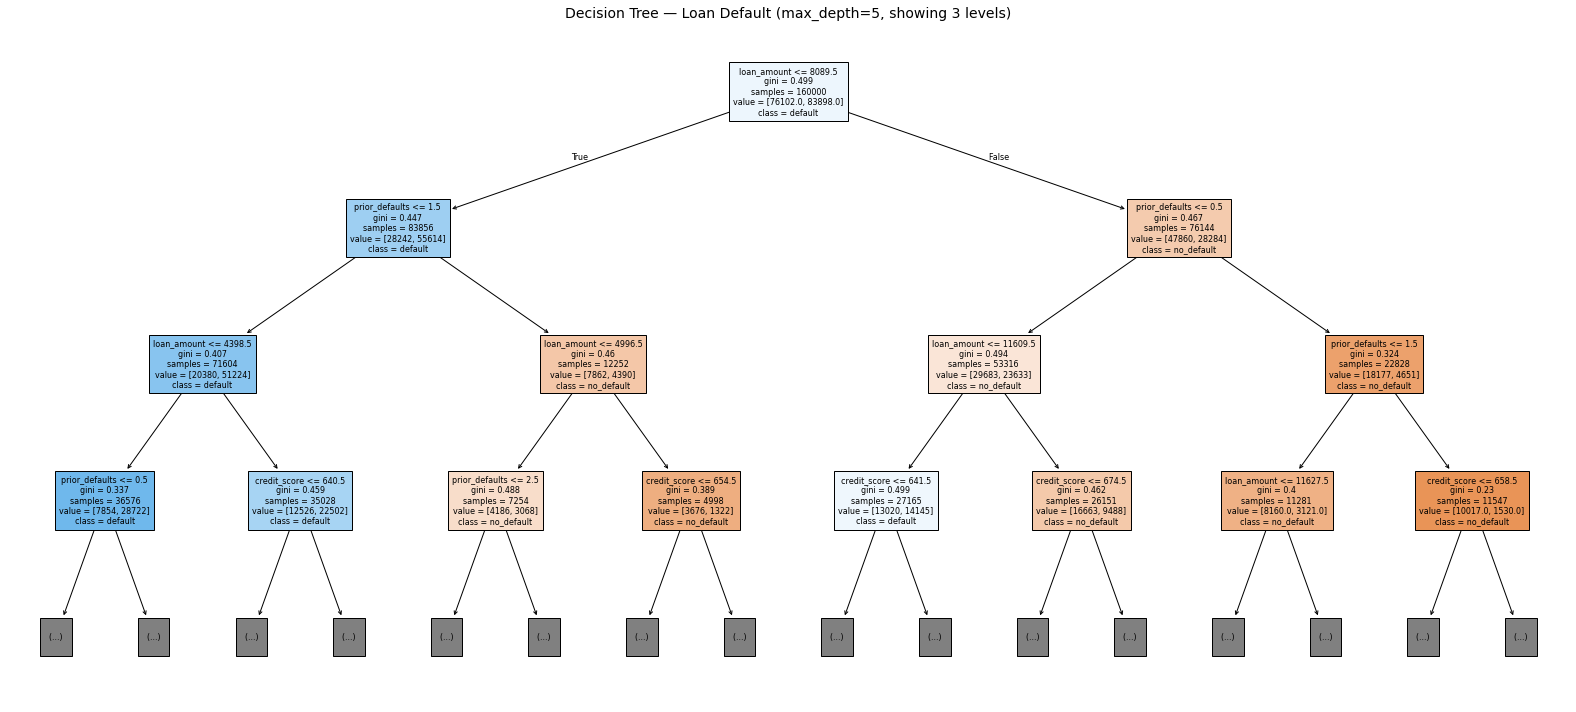

In [5]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["no_default", "default"],
    filled=True,
    max_depth=3,
    ax=ax,
    fontsize=8
)
plt.title("Decision Tree — Loan Default (max_depth=5, showing 3 levels)", fontsize=14)
plt.tight_layout()
plt.show()

---
## Section 5 — Overfitting: Capped vs. Uncapped Tree

In [6]:
tree_deep = DecisionTreeClassifier(random_state=42)
tree_deep.fit(X_train, y_train)

print(f"Deep tree  — Train accuracy: {tree_deep.score(X_train, y_train):.4f}")
print(f"Deep tree  — Test  accuracy: {tree_deep.score(X_test,  y_test):.4f}")
print()
print(f"Capped tree — Train accuracy: {tree.score(X_train, y_train):.4f}")
print(f"Capped tree — Test  accuracy: {tree.score(X_test,  y_test):.4f}")
print()
print(f"Deep tree max_depth reached: {tree_deep.get_depth()}")

Deep tree  — Train accuracy: 1.0000
Deep tree  — Test  accuracy: 0.6084

Capped tree — Train accuracy: 0.6918
Capped tree — Test  accuracy: 0.6933

Deep tree max_depth reached: 50


---
## Section 6 — Random Forest & Feature Importances

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest (default) — Classification Report")
print(classification_report(y_test, y_pred_rf, target_names=["no_default", "default"]))

Random Forest (default) — Classification Report
              precision    recall  f1-score   support

  no_default       0.67      0.66      0.67     19026
     default       0.70      0.71      0.70     20974

    accuracy                           0.69     40000
   macro avg       0.68      0.68      0.68     40000
weighted avg       0.69      0.69      0.69     40000



         Feature  Importance
     loan_amount    0.325203
  monthly_income    0.216752
    credit_score    0.201087
employment_years    0.176086
  prior_defaults    0.070671
  has_collateral    0.010201


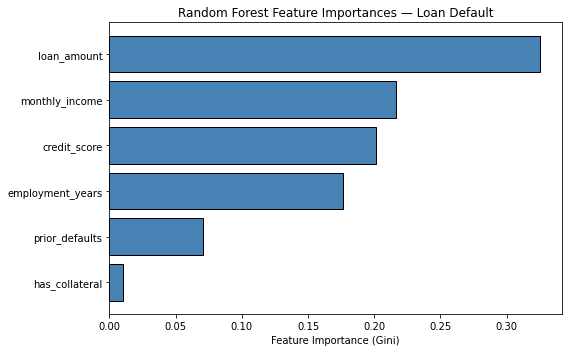

In [8]:
importances = rf.feature_importances_
importance_df = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    color="steelblue",
    edgecolor="black"
)
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Random Forest Feature Importances — Loan Default")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## Section 7 — Class Weighting: Default vs. Balanced

In [9]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_balanced.fit(X_train, y_train)
y_pred_balanced = rf_balanced.predict(X_test)

print("Default RF:")
print(classification_report(y_test, y_pred_rf, target_names=["no_default", "default"], digits=3))
print("\nBalanced RF:")
print(classification_report(y_test, y_pred_balanced, target_names=["no_default", "default"], digits=3))

Default RF:
              precision    recall  f1-score   support

  no_default      0.672     0.662     0.667     19026
     default      0.697     0.708     0.703     20974

    accuracy                          0.686     40000
   macro avg      0.685     0.685     0.685     40000
weighted avg      0.686     0.686     0.686     40000


Balanced RF:
              precision    recall  f1-score   support

  no_default      0.673     0.657     0.665     19026
     default      0.695     0.711     0.703     20974

    accuracy                          0.685     40000
   macro avg      0.684     0.684     0.684     40000
weighted avg      0.685     0.685     0.685     40000



---
## Section 8 — Precision-Recall Curves & PR-AUC

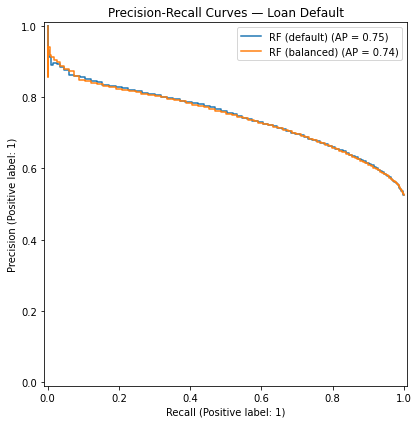

PR-AUC (default):  0.7466
PR-AUC (balanced): 0.7448


In [10]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

fig, ax = plt.subplots(figsize=(9, 6))

PrecisionRecallDisplay.from_estimator(
    rf,          X_test, y_test, name="RF (default)",  ax=ax
)
PrecisionRecallDisplay.from_estimator(
    rf_balanced, X_test, y_test, name="RF (balanced)", ax=ax
)

ax.set_title("Precision-Recall Curves — Loan Default")
ax.legend()
plt.tight_layout()
plt.show()

pr_auc_default  = average_precision_score(y_test, rf.predict_proba(X_test)[:, 1])
pr_auc_balanced = average_precision_score(y_test, rf_balanced.predict_proba(X_test)[:, 1])
print(f"PR-AUC (default):  {pr_auc_default:.4f}")
print(f"PR-AUC (balanced): {pr_auc_balanced:.4f}")

---
## Section 9 — Advanced Technique 1: SMOTE (Synthetic Minority Over-Sampling)

**What it does:** SMOTE generates *synthetic* minority-class samples by interpolating between real minority examples in feature space, rather than simply duplicating existing ones. This forces the model to learn a denser minority decision boundary.

**Why it differs from class weighting:** Class weighting adjusts the loss function at training time but never changes the training data itself. SMOTE physically changes the training set — new artificial default applicants are injected — so the model sees a truly balanced distribution during fitting.

In [18]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to the training set — never touch the test set
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE — training samples: {len(X_train):,}")
print(f"Before SMOTE — default rate:     {y_train.mean():.1%}")
print()
print(f"After  SMOTE — training samples: {len(X_train_sm):,}")
print(f"After  SMOTE — default rate:     {y_train_sm.mean():.1%}")

Before SMOTE — training samples: 160,000
Before SMOTE — default rate:     52.4%

After  SMOTE — training samples: 167,796
After  SMOTE — default rate:     50.0%


In [19]:
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_sm, y_train_sm)
y_pred_smote = rf_smote.predict(X_test)

print("RF + SMOTE — Classification Report")
print(classification_report(y_test, y_pred_smote, target_names=["no_default", "default"], digits=3))

pr_auc_smote = average_precision_score(y_test, rf_smote.predict_proba(X_test)[:, 1])
print(f"PR-AUC (SMOTE): {pr_auc_smote:.4f}")

RF + SMOTE — Classification Report
              precision    recall  f1-score   support

  no_default      0.661     0.684     0.672     19026
     default      0.704     0.681     0.692     20974

    accuracy                          0.682     40000
   macro avg      0.682     0.683     0.682     40000
weighted avg      0.683     0.682     0.683     40000

PR-AUC (SMOTE): 0.7455


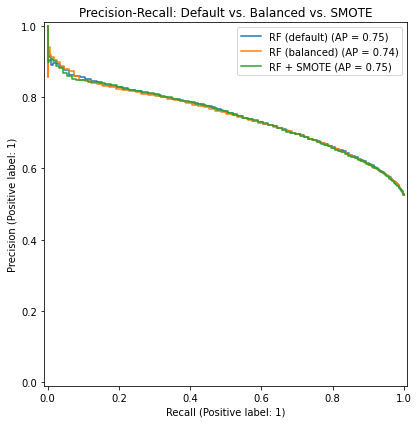

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))

PrecisionRecallDisplay.from_estimator(rf,          X_test, y_test, name="RF (default)",  ax=ax)
PrecisionRecallDisplay.from_estimator(rf_balanced, X_test, y_test, name="RF (balanced)", ax=ax)
PrecisionRecallDisplay.from_estimator(rf_smote,    X_test, y_test, name="RF + SMOTE",    ax=ax)

ax.set_title("Precision-Recall: Default vs. Balanced vs. SMOTE")
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 10 — Advanced Technique 2: Domain-Driven Feature Engineering

**What it does:** We construct three new features that encode domain knowledge a tree cannot learn on its own from raw columns alone:
- `debt_to_income_ratio` — loan amount relative to monthly income (high DTI → higher default risk)
- `credit_risk_score` — weighted combination of credit score and prior defaults (combines two signals)
- `income_stability` — employment years divided by (monthly income / 1000) (longer tenure relative to income suggests stability)

**Why it differs from regularization:** Regularization penalizes model complexity after the fact. Feature engineering changes *what information* is available to the model — it is a data transformation, not a training constraint.

In [21]:
def add_engineered_features(df):
    out = df.copy()
    # Ratio of loan size to monthly income — high values signal repayment strain
    out["debt_to_income_ratio"] = out["loan_amount"] / (out["monthly_income"] + 1)
    # Composite credit risk: penalise low credit scores and prior default history
    out["credit_risk_score"]    = out["credit_score"] - (out["prior_defaults"] * 50)
    # Employment stability relative to income level
    out["income_stability"]     = out["employment_years"] / (out["monthly_income"] / 1000 + 0.01)
    return out

X_train_fe = add_engineered_features(X_train)
X_test_fe  = add_engineered_features(X_test)

print("New feature columns added:")
print(X_train_fe.columns.tolist())
print()
print(X_train_fe[["debt_to_income_ratio", "credit_risk_score", "income_stability"]].describe().round(3))

New feature columns added:
['monthly_income', 'employment_years', 'loan_amount', 'credit_score', 'prior_defaults', 'has_collateral', 'debt_to_income_ratio', 'credit_risk_score', 'income_stability']

       debt_to_income_ratio  credit_risk_score  income_stability
count            160000.000         160000.000        160000.000
mean                  7.992            625.079             5.083
std                   6.456             90.378             6.280
min                   0.074            179.000             0.000
25%                   3.320            566.000             1.199
50%                   6.461            628.000             3.037
75%                  10.857            687.000             6.574
max                 114.073            850.000           127.273


In [22]:
rf_fe = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_fe.fit(X_train_fe, y_train)
y_pred_fe = rf_fe.predict(X_test_fe)

print("RF + Feature Engineering — Classification Report")
print(classification_report(y_test, y_pred_fe, target_names=["no_default", "default"], digits=3))

pr_auc_fe = average_precision_score(y_test, rf_fe.predict_proba(X_test_fe)[:, 1])
print(f"PR-AUC (feature engineering): {pr_auc_fe:.4f}")

RF + Feature Engineering — Classification Report
              precision    recall  f1-score   support

  no_default      0.670     0.658     0.664     19026
     default      0.695     0.706     0.701     20974

    accuracy                          0.683     40000
   macro avg      0.683     0.682     0.682     40000
weighted avg      0.683     0.683     0.683     40000

PR-AUC (feature engineering): 0.7453


             Feature  Importance
         loan_amount    0.210009
debt_to_income_ratio    0.156335
    income_stability    0.123143
      monthly_income    0.122185
   credit_risk_score    0.121925
    employment_years    0.102921
        credit_score    0.099863
      prior_defaults    0.049329
      has_collateral    0.014290


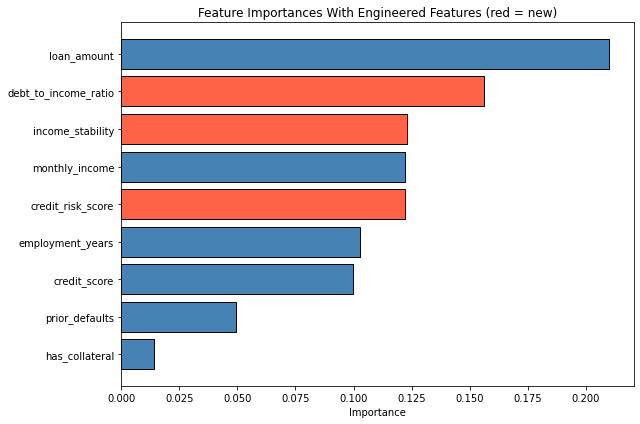

In [23]:
fe_importances = rf_fe.feature_importances_
fe_importance_df = pd.DataFrame({
    "Feature":    X_train_fe.columns,
    "Importance": fe_importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print(fe_importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["tomato" if "ratio" in f or "risk" in f or "stability" in f else "steelblue"
          for f in fe_importance_df["Feature"]]
ax.barh(fe_importance_df["Feature"], fe_importance_df["Importance"],
        color=colors, edgecolor="black")
ax.set_xlabel("Importance")
ax.set_title("Feature Importances With Engineered Features (red = new)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## Section 11 — Advanced Technique 3: Optimal Threshold Selection via Cost-Sensitive Cutoff

**What it does:** Every classifier's `.predict()` method applies a default decision threshold of 0.5 — the model predicts "default" when `predict_proba >= 0.5`. But 0.5 is almost never the *optimal* threshold for an imbalanced problem. We compute the F-beta score (beta=2, which weights recall twice as heavily as precision) across every possible threshold and select the one that maximises it.

**Why beta=2?** In microfinance, missing a real default (false negative) is more costly than a false alarm (false positive). Recall therefore deserves more weight. F2 encodes this business judgment mathematically without re-training the model at all — it changes where we draw the line on the probability output.

**Why it differs from the other techniques:** SMOTE and feature engineering act during data preparation and training. Threshold tuning acts after training, on the raw probability scores. It does not change the model's learned parameters — only the rule we apply to its output.

In [24]:
from sklearn.metrics import precision_recall_curve, fbeta_score, classification_report

# Use the balanced RF probabilities as the base model
proba_balanced = rf_balanced.predict_proba(X_test)[:, 1]

# Sweep every threshold suggested by the precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, proba_balanced)

# Compute F2 at every threshold (beta=2 weights recall over precision)
beta = 2
f2_scores = (
    (1 + beta**2) * precisions[:-1] * recalls[:-1]
    / ((beta**2 * precisions[:-1]) + recalls[:-1] + 1e-9)
)

best_idx       = f2_scores.argmax()
best_threshold = thresholds[best_idx]
best_f2        = f2_scores[best_idx]

print(f"Best threshold (F2-maximising): {best_threshold:.4f}")
print(f"F2 score at best threshold:     {best_f2:.4f}")

Best threshold (F2-maximising): 0.1300
F2 score at best threshold:     0.8524


In [25]:
# Apply the optimal threshold instead of the default 0.5
y_pred_optimal = (proba_balanced >= best_threshold).astype(int)

print(f"--- Balanced RF at default threshold (0.50) ---")
print(classification_report(y_test, y_pred_balanced, target_names=["no_default", "default"], digits=3))

print(f"--- Balanced RF at optimal threshold ({best_threshold:.4f}) ---")
print(classification_report(y_test, y_pred_optimal, target_names=["no_default", "default"], digits=3))

--- Balanced RF at default threshold (0.50) ---
              precision    recall  f1-score   support

  no_default      0.673     0.657     0.665     19026
     default      0.695     0.711     0.703     20974

    accuracy                          0.685     40000
   macro avg      0.684     0.684     0.684     40000
weighted avg      0.685     0.685     0.685     40000

--- Balanced RF at optimal threshold (0.1300) ---
              precision    recall  f1-score   support

  no_default      0.888     0.119     0.209     19026
     default      0.552     0.986     0.708     20974

    accuracy                          0.574     40000
   macro avg      0.720     0.552     0.459     40000
weighted avg      0.712     0.574     0.471     40000



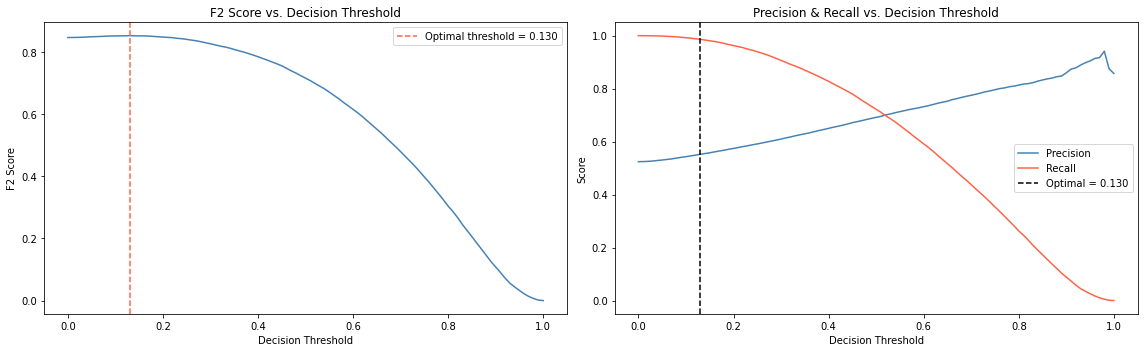

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F2 vs. threshold
axes[0].plot(thresholds, f2_scores, color="steelblue", linewidth=1.5)
axes[0].axvline(best_threshold, color="tomato", linestyle="--",
                label=f"Optimal threshold = {best_threshold:.3f}")
axes[0].set_xlabel("Decision Threshold")
axes[0].set_ylabel("F2 Score")
axes[0].set_title("F2 Score vs. Decision Threshold")
axes[0].legend()

# Precision & Recall vs. threshold
axes[1].plot(thresholds, precisions[:-1], label="Precision", color="steelblue", linewidth=1.5)
axes[1].plot(thresholds, recalls[:-1],    label="Recall",    color="tomato",    linewidth=1.5)
axes[1].axvline(best_threshold, color="black", linestyle="--",
                label=f"Optimal = {best_threshold:.3f}")
axes[1].set_xlabel("Decision Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision & Recall vs. Decision Threshold")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Section 12 — Final Model Comparison

In [27]:
from sklearn.metrics import recall_score, precision_score, f1_score

models = {
    "Decision Tree (max_depth=5)": y_pred_tree,
    "RF default": y_pred_rf,
    "RF balanced": y_pred_balanced,
    "RF + SMOTE": y_pred_smote,
    "RF + Feature Eng.": y_pred_fe,
    "RF balanced + Optimal Threshold": y_pred_optimal,
}

rows = []
for name, preds in models.items():
    rows.append({
        "Model": name,
        "Accuracy":  round((preds == y_test).mean(), 4),
        "Precision (default)": round(precision_score(y_test, preds, zero_division=0), 4),
        "Recall (default)": round(recall_score(y_test, preds), 4),
        "F1 (default)": round(f1_score(y_test, preds), 4),
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

                          Model  Accuracy  Precision (default)  Recall (default)  F1 (default)
    Decision Tree (max_depth=5)    0.6933               0.6974            0.7333        0.7149
                     RF default    0.6857               0.6974            0.7077        0.7025
                    RF balanced    0.6851               0.6954            0.7110        0.7031
                     RF + SMOTE    0.6824               0.7036            0.6815        0.6924
              RF + Feature Eng.    0.6835               0.6949            0.7065        0.7007
RF balanced + Optimal Threshold    0.5736               0.5523            0.9865        0.7081


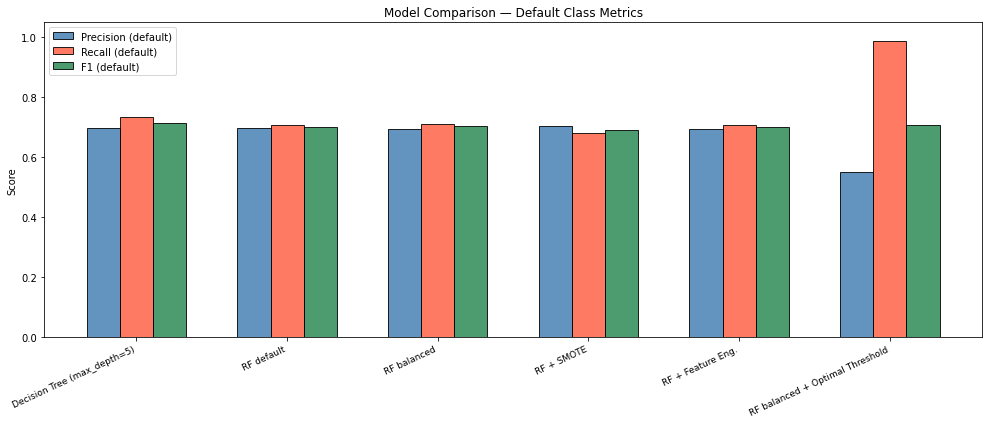

In [28]:
fig, ax = plt.subplots(figsize=(14, 6))

x       = range(len(comparison_df))
width   = 0.22
metrics = ["Precision (default)", "Recall (default)", "F1 (default)"]
colors  = ["steelblue", "tomato", "seagreen"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    offsets = [xi + i * width for xi in x]
    ax.bar(offsets, comparison_df[metric], width=width, label=metric,
           color=color, alpha=0.85, edgecolor="black")

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(comparison_df["Model"], rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Default Class Metrics")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

---
## Key Takeaways

| Concept | What to remember |
|---|---|
| Imbalanced classes | Accuracy is a misleading metric when one class is rare — always report recall and PR-AUC for the minority class |
| max_depth | Without it, a decision tree memorises the training set (100% train accuracy, poor test accuracy) — always set a depth limit |
| class_weight='balanced' | Shifts the model's loss function to penalise minority-class errors more; recall rises, precision typically falls |
| Feature importances | Measure split utility, not linear correlation — a feature can be important even with low Pearson r |
| SMOTE | Synthesises minority samples in feature space before training; a data-level fix vs. class weighting's loss-level fix |
| Feature engineering | Domain-informed transformations (DTI ratio, composite risk score) give the model pre-compressed signals that raw features cannot |
| Threshold optimisation | Post-training: choosing a threshold < 0.5 trades some precision for higher recall — encoded via F-beta score with beta=2 for loan default |
| PR-AUC vs ROC-AUC | For imbalanced data, PR-AUC is the more informative summary — it focuses entirely on the minority class |